The Superstore sales dataset will be analyzed to determine if sales can be predicted based on the timing of customers orders. The dataset includes variables such as order dates, ship dates, customers,   product information and sales figure. After reviewing the dataset structure, I will attempt to identify missing and problematic values. Clean the order date variable and create the days variable representing the number of days of sales over time. Using Python, a scatter plot and a histogram will be used to examine the linear relationship between time and sales. An evaluation of the modeln will be done using  perfomance metrics suchas R-squared, mean absolute error(MAE) and root mean square error (RMSE). Finally the results will be interpreted and discussed to determine if time is a useful predictoe os Superstore sales.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv('train.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
df.describe()

In [ ]:

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

df['Days'] = (df['Order Date'] - df['Order Date'].min()).dt.days

df[['Order Date', 'Days', 'Sales']].head()

,Order Date,Days,Sales
0,2017-11-08,1040,261.9600
1,2017-11-08,1040,731.9400
2,2017-06-12,891,14.6200
3,2016-10-11,647,957.5775
4,2016-10-11,647,22.3680


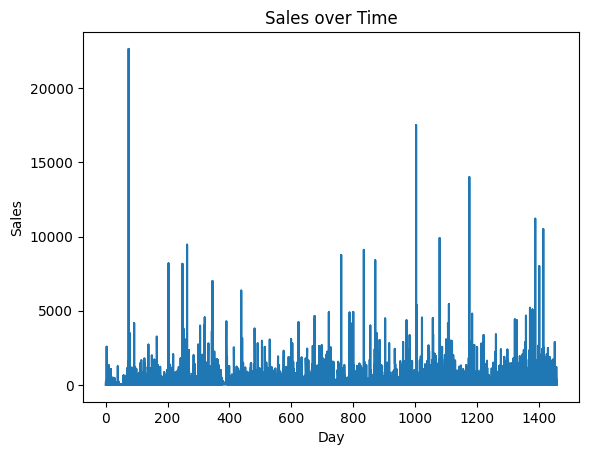

In [ ]:
import matplotlib.pyplot as plt

df = df.sort_values('Days')

x=df['Days']
y=df['Sales']

plt.plot(x,y)
plt.xlabel('Day')
plt.ylabel('Sales')
plt.title('Sales over Time')
plt.show()

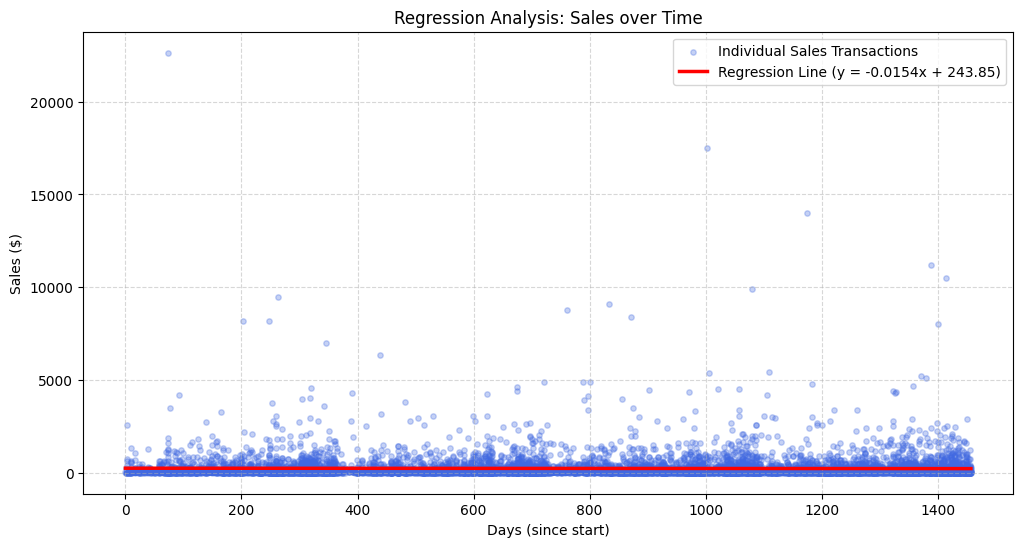

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = df['Days']
y = df['Sales']

m, c = np.polyfit(x, y, 1)

plt.figure(figsize=(12, 6))
plt.scatter(x, y, alpha=0.3, color='royalblue', label='Individual Sales Transactions', s=15)

plt.plot(x, m*x + c, color='red', linewidth=2.5, label=f'Regression Line (y = {m:.4f}x + {c:.2f})')

plt.xlabel('Days (since start)')
plt.ylabel('Sales ($)')
plt.title('Regression Analysis: Sales over Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== Linear Regression Model Evaluation ===
Mean Absolute Error (MAE): $1763.73
R-squared Score: 0.0599


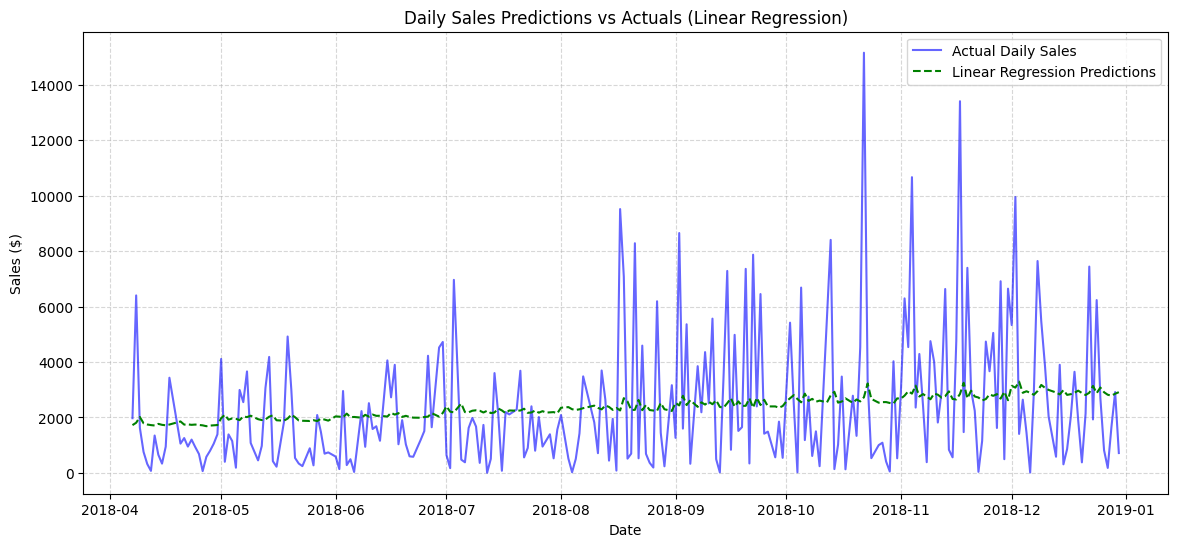

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("=== Linear Regression Model Evaluation ===")
print(f"Mean Absolute Error (MAE): ${lr_mae:.2f}")
print(f"R-squared Score: {lr_r2:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(daily_df['Order Date'].iloc[split_idx:], y_test, label='Actual Daily Sales', color='blue', alpha=0.6)
plt.plot(daily_df['Order Date'].iloc[split_idx:], lr_predictions, label='Linear Regression Predictions', color='green', linestyle='--')
plt.title('Daily Sales Predictions vs Actuals (Linear Regression)')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
print(f'Root Mean Squared Error (RMSE): ${rmse:.2f}')

Root Mean Squared Error (RMSE): $2378.19


The final analysis used a linear regression model to examine whether the timing of orders could predict sales in the Superstore dataset. Data cleaning and preparation were completed before the analysis. A scatter plot and histogram were used to explore the data and identify unusually high sales values. The model produced a Mean Absolute Error (MAE) of $1,763.73, meaning that prdictions differed from actual sales by approximately $1,764 on average. The R-squared value was 0.0599 showinf=g the model expained 6% of the variation in sales. The Root Mean Squared Error. Showing large predictive errors. This model shows that timing alone is not an accurate predictor of sales. Other variables and regression models may be more suited.   

Gemini was used in the coding of this assignment.